# Day 1 Project: 택시 이용내역 데이터

프로젝트 수행 방법   

이번 프로젝트에서 사용할 데이터 이름은 trip.csv입니다.
다양한 변수들을 활용하여 “택시 요금”을 예측한다는 가정하에 데이터를 정제해보세요.

지금까지 배운 내용을 최대한 활용하여 문제가 되는 부분을 찾아 정리하고, 최대한 변수들을 머신러닝 알고리즘에 활용 가능하도록 만들어봅시다.   
만약 이전에 배웠던 학습 내용이 익숙하지 않다면  이전학습을 다시 한번 복습해 주세요. 🤗


먼저 필요한 라이브러리를 import해 볼까요?   
Step 1. 이것만큼은 꼭 해보세요!   
프로젝트에 정답은 없습니다. 배우신 내용을 토대로 자유롭게 데이터를 정제하되, 아래 내용만큼은 반드시 실습해봅시다.   

결측치 판단 및 처리   
[힌트] 결측치의 유무와 비율을 살펴보고 적절한 방법으로 처리합니다.   
이상치 판단 및 처리   
[힌트] 숫자형 변수 각각에 대해, 데이터의 index와 변수 값 사이의 scatter plot을 그려보고 이상치가 관찰될 경우 제거합니다.   
Step 2. 이런것도 해볼 수 있어요!   
자유롭게 실습을 해보시고, 여유가 되면 아래의 내용도 실습해보세요.   

택시 탑승 및 하차 시간을 활용할 수 있을지 고민해보세요.   
[힌트] 택시의 주행 시간과 주행 거리, 요금 등의 상관 관계도 살펴볼 수 있겠죠?   
Credit Card와 Debit Card를 구분없이 "Card"라는 이름으로 만들어 보세요.   

In [100]:
# 라이브러리 임폴트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


#  데이터 불러오기

df = pd.read_csv("../00_Dataset/trip.csv")  # ../00_Dataset/는 노트북 폴더의 상위 폴더에 있는 00_Dataset
print("✅ 데이터 로드 완료!")
print("행/열 크기(shape):", df.shape)
print("-" * 60)

# 데이터 라벨링(컬럼 정의) 표 만들기


# 컬럼 정의표(Data Dictionary)
label_df = pd.DataFrame({
    "컬럼명": [
        "passenger_name",
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "payment_method",
        "passenger_count",
        "trip_distance",
        "fare_amount",
        "tip_amount",
        "tolls_amount"
    ],
    "의미": [
        "승객 이름",
        "택시 탑승 시간",
        "택시 하차 시간",
        "결제 방식",
        "탑승 인원 수",
        "이동 거리",
        "기본 요금",
        "팁 금액",
        "톨게이트 요금"
    ],
    
    "모델 활용 여부": [
        "❌ 제거 후보(식별자)",
        "⭕ 파생 변수 생성",
        "⭕ 파생 변수 생성",
        "⭕ 사용 가능(전처리 필요)",
        "⭕ 사용 가능",
        "⭐ 매우 중요",
        "🎯 예측 대상",
        "⭕ 보조 변수",
        "⭕ 보조 변수"
    ]
})



display(df)
display(df.head(10))  # 데이터프레임의 처음 10행 출력
display(df.info())  # 데이터프레임 정보 출력
display(label_df)



✅ 데이터 로드 완료!
행/열 크기(shape): (22701, 9)
------------------------------------------------------------


,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
0,Pamela Duffy,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,Debit Card,6,3.34,13.0,2.76,0.00
1,Michelle Foster,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,Debit Card,1,1.80,16.0,4.00,0.00
2,Tina Combs,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,Debit Card,1,1.00,6.5,1.45,0.00
3,Anthony Ray,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,Cash,1,3.70,20.5,6.39,0.00
4,Brianna Johnson,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,Debit Card,1,4.37,16.5,0.00,0.00
...,...,...,...,...,...,...,...,...,...
22696,Austin Johnson,02/24/2017 5:37:23 PM,02/24/2017 5:40:39 PM,Cash,3,0.61,4.0,0.00,0.00
22697,Monique Williams,08/06/2017 4:43:59 PM,08/06/2017 5:24:47 PM,Cash,1,16.71,52.0,14.64,5.76
22698,Drew Graves,09/04/2017 2:54:14 PM,09/04/2017 2:58:22 PM,Debit Card,1,0.42,4.5,0.00,0.00
22699,Jonathan Copeland,07/15/2017 12:56:30 PM,07/15/2017 1:08:26 PM,Debit Card,1,2.36,10.5,1.70,0.00


,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
0,Pamela Duffy,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,Debit Card,6,3.34,13.0,2.76,0.0
1,Michelle Foster,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,Debit Card,1,1.80,16.0,4.00,0.0
2,Tina Combs,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,Debit Card,1,1.00,6.5,1.45,0.0
3,Anthony Ray,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,Cash,1,3.70,20.5,6.39,0.0
4,Brianna Johnson,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,Debit Card,1,4.37,16.5,0.00,0.0
5,Justin Smith,03/25/2017 8:34:11 PM,03/25/2017 8:42:11 PM,Debit Card,6,2.30,9.0,2.06,0.0
6,Tonya Moreno,05/03/2017 7:04:09 PM,05/03/2017 8:03:47 PM,Cash,1,12.83,47.5,9.86,0.0
7,Hannah Foley,08/15/2017 5:41:06 PM,08/15/2017 6:03:05 PM,Debit Card,1,2.98,16.0,1.78,0.0
8,Katie Whitney,02/04/2017 4:17:07 PM,02/04/2017 4:29:14 PM,Cash,1,1.20,9.0,0.00,0.0
9,Amanda Jones,11/10/2017 3:20:29 PM,11/10/2017 3:40:55 PM,Cash,1,1.60,13.0,2.75,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22701 entries, 0 to 22700
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   passenger_name         22701 non-null  object 
 1   tpep_pickup_datetime   22701 non-null  object 
 2   tpep_dropoff_datetime  22701 non-null  object 
 3   payment_method         22701 non-null  object 
 4   passenger_count        22701 non-null  int64  
 5   trip_distance          22701 non-null  float64
 6   fare_amount            22698 non-null  float64
 7   tip_amount             22701 non-null  float64
 8   tolls_amount           22701 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 1.6+ MB


None

,컬럼명,의미,모델 활용 여부
0,passenger_name,승객 이름,❌ 제거 후보(식별자)
1,tpep_pickup_datetime,택시 탑승 시간,⭕ 파생 변수 생성
2,tpep_dropoff_datetime,택시 하차 시간,⭕ 파생 변수 생성
3,payment_method,결제 방식,⭕ 사용 가능(전처리 필요)
4,passenger_count,탑승 인원 수,⭕ 사용 가능
5,trip_distance,이동 거리,⭐ 매우 중요
6,fare_amount,기본 요금,🎯 예측 대상
7,tip_amount,팁 금액,⭕ 보조 변수
8,tolls_amount,톨게이트 요금,⭕ 보조 변수


<span style="background-color:#FFF3B0; color:#000; font-weight:bold;">
→ 데이터는 총 22701개이며 9개의 컬럼으로 나뉜다.<br>이중 승객이름/ 승차시간, 하차시간, 지불방법은 범주형<br> 승객수는 정수형이며<br> 주행거리, 기본요금, 팁금액, 톨게이트 비용은 금액으로 실수형 데이터이다.<br> 이 중 결측치가 있는 컬럼은 기본요금을 나타내는 fare_amount 컬럼이며 결측치 3개가 존재한다.<br></span>  <span style="background-color: #d0fc5c; color:#000; font-weight:bold;">→그렇다면 결측치는 정확히 어디에 있고 몇개가 있고 비율은 얼마나 되는지 알아보자.
</span>

In [101]:
#컬럼별 결측치 개수 계산
missing_count = df.isnull().sum()

#컬럼별 결측치 비율(%) 계산
# True = 1, False = 0 이라서 mean()을 쓰면 비율이 됨
missing_ratio = (df.isnull().mean() * 100).round(2)

# 보기 좋은 표로 정리
missing_summary = pd.DataFrame({
    "결측치 개수": missing_count,
    "결측치 비율(%)": missing_ratio
})

#결측치 비율이 높은 컬럼부터 정렬
missing_summary = missing_summary.sort_values(
    by="결측치 비율(%)",
    ascending=False
)

# 결과 출력
missing_summary

,결측치 개수,결측치 비율(%)
fare_amount,3,0.01
passenger_name,0,0.00
tpep_pickup_datetime,0,0.00
tpep_dropoff_datetime,0,0.00
payment_method,0,0.00
passenger_count,0,0.00
trip_distance,0,0.00
tip_amount,0,0.00
tolls_amount,0,0.00


# 1.누락된 결측치 처리 (Missing values)
<span style="background-color:#FFF3B0; color:#000; font-weight:bold;">
→ 결측치가 있는 컬럼은 기본요금을 나타내는 fare_amount 컬럼이며 결측치 3개가 존재한다.<br>비율은 0.01%이다.<br>결측치가 있는 행은 지우도록 하자</span>

In [57]:
# fare_amount에 결측치가 있는 행 제거
# df = df.dropna(subset=["fare_amount"])

df.dropna(subset=["fare_amount"], inplace=True)

# 잘 제거됐는지 확인
df.isnull().sum()

passenger_name           0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
payment_method           0
passenger_count          0
trip_distance            0
fare_amount              0
tip_amount               0
tolls_amount             0
dtype: int64

<span style="background-color:#FFF3B0; color:#000; font-weight:bold;">
→ 결측치없이 모두 잘 처리되었다.<br>이제 이상치를 확인하자.<br>이상치는 대부분의 데이터들과 너무 동떨어진 값을 말하며 그것을 스캐터 플롯 시각화를 통해 더 한눈에 알아보자.</span>

숫자형 컬럼: ['passenger_count', 'trip_distance', 'fare_amount', 'tip_amount', 'tolls_amount']


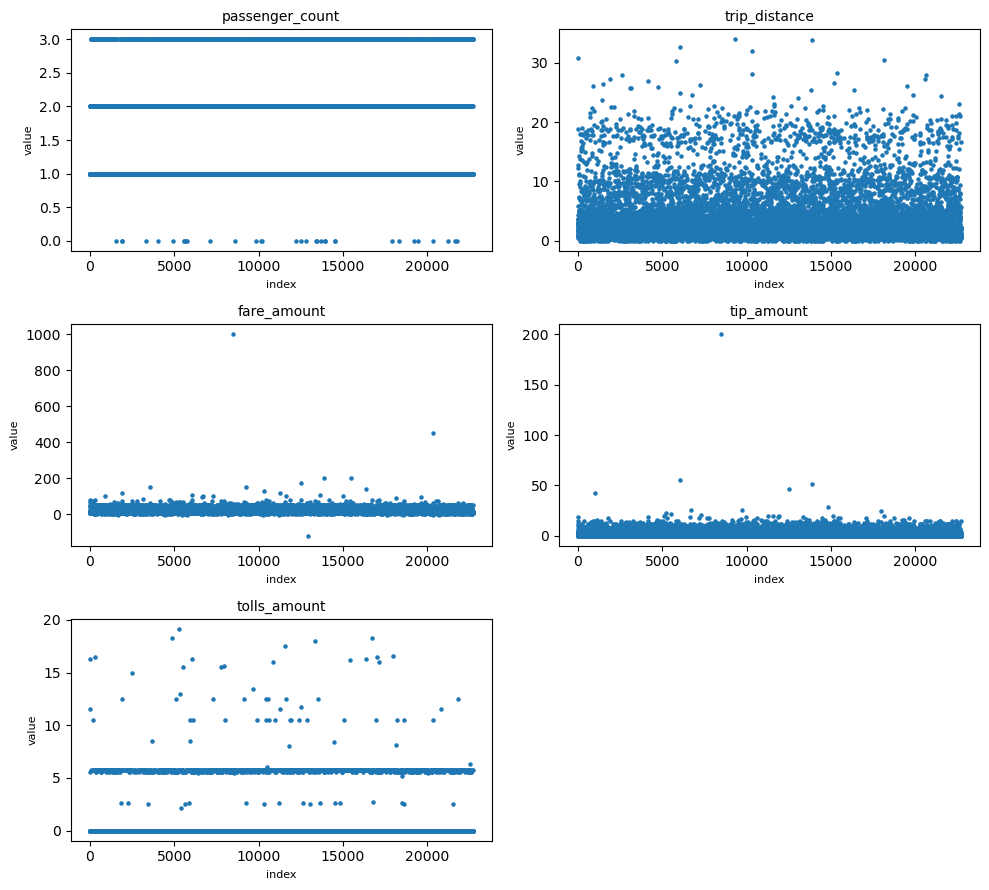


IQR 기준 이상치 후보 요약(개수/비율)


,컬럼,하한(lower),상한(upper),이상치 후보 개수,이상치 후보 비율(%)
0,passenger_count,1.000,1.000,4291,21.02
1,trip_distance,-2.100,6.140,2265,11.10
2,fare_amount,-5.500,26.500,1848,9.05
3,tip_amount,-3.675,6.125,1074,5.26
4,tolls_amount,0.000,0.000,1051,5.15


In [77]:
#숫자형 컬럼만 뽑기 (이상치는 보통 숫자에서 먼저 확인)
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
print("숫자형 컬럼:", list(numeric_cols))

# 과제 힌트: index(행 번호) vs 변수값 scatter plot 그리기

# subplot 개수 계산
n_cols = 2  # 한 줄에 그래프 2개
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

# 전체 그림 크기 작게 설정
plt.figure(figsize=(10, 3 * n_rows))

# 각 숫자형 변수별 scatter plot 그리기
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.scatter(df.index, df[col], s=5)  # 점 크기 작게
    plt.title(col, fontsize=10)
    plt.xlabel("index", fontsize=8)
    plt.ylabel("value", fontsize=8)

# 그래프 간격 자동 조정
plt.tight_layout()
plt.show()    
    
    # =========================================================
# B) (추가) IQR 방식으로 이상치 '후보' 개수/비율 계산
# - IQR: 중간 50% 범위(=Q3-Q1)를 기준으로 너무 큰/작은 값을 이상치 후보로 봐요
# - 기준: [Q1 - 1.5*IQR, Q3 + 1.5*IQR] 밖이면 outlier 후보
# =========================================================

outlier_summary = []

for col in numeric_cols:
    # 요약통계를 위해 결측치 제거한 값으로 계산
    x = df[col].dropna()

    # 1사분위(Q1), 3사분위(Q3)
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1

    # 이상치 후보 경계값 계산
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # 이상치 후보 마스크(True/False)
    is_outlier = (df[col] < lower) | (df[col] > upper)

    # 개수/비율 저장
    outlier_count = int(is_outlier.sum())
    outlier_ratio = round(outlier_count / len(df) * 100, 2)

    outlier_summary.append([col, lower, upper, outlier_count, outlier_ratio])

# 표로 정리
outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["컬럼", "하한(lower)", "상한(upper)", "이상치 후보 개수", "이상치 후보 비율(%)"]
).sort_values(by="이상치 후보 비율(%)", ascending=False)

print("\nIQR 기준 이상치 후보 요약(개수/비율)")
outlier_df

# 2. 이상치를 제거하자

<span style="background-color:#FFF3B0; color:#000; font-weight:bold;">
어떤 이상치를 제거할까?<br> 1.택시 승객수가 30이상으로 나온 이상치는 제거하자 <br> 그밖에는 거리와 비례하여 대입되는 부분이 발견되므로 제거할 필요는 없고 팁은 주관적 선택적 행동이므로 패턴화할수 없고 주요 변수로 둘 만큼 비중있진 않으므로 그대로 두기 결정!<br> → 그럼 승객수의 이상치만 제거하자<br>그런데 통상 택시에 몇 명까지 탈 수 있는지 모르는데?<br>일단 그럼 30명 넘는 데이터만 지워보자 뭐가 남는지</span> 

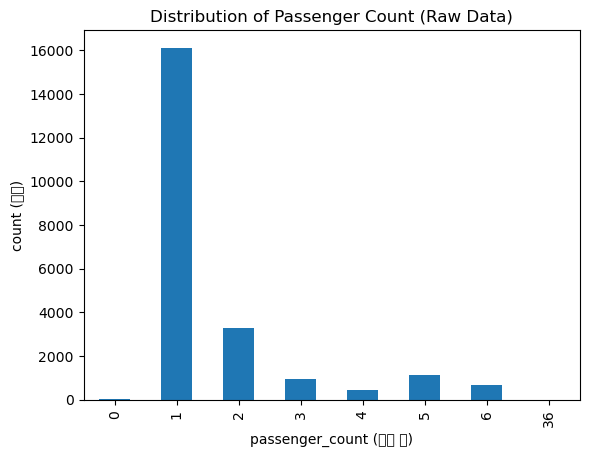

In [79]:
# 1. 원본 데이터 다시 불러오기 (아무 정제도 안 된 상태)
df_raw = pd.read_csv("../00_Dataset/trip.csv")

# 2. 승객수 전체 분포 확인 (숫자)
df_raw["passenger_count"].value_counts().sort_index()

# 3. 승객수 전체 분포 시각화
df_raw["passenger_count"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("passenger_count (승객 수)")
plt.ylabel("count (건수)")
plt.title("Distribution of Passenger Count (Raw Data)")
plt.show()

<span style="background-color:#FFF3B0; color:#000; font-weight:bold;">
36명 승객을 태운것과 0명 승객을 태웠다는것은 말이 안되자나... <br>
0명을 태운것도 불확실한 정보야.   <br>
해당 컬럼의 데이터를 정렬해보자  </span>

In [82]:
df_raw["passenger_count"].value_counts().sort_index()

passenger_count
0        33
1     16119
2      3305
3       953
4       455
5      1143
6       692
36        1
Name: count, dtype: int64

<span style="background-color:#FFF3B0; color:#000; font-weight:bold;">
36명과 0명이 들어있는 행은 지우자 <br>
그리고 원래 데이터와 비교해보자</span>

📌 제거 전 데이터 크기: (22698, 9)

📌 제거 전 passenger_count 분포:
passenger_count
0        33
1     16117
2      3305
3       952
4       455
5      1143
6       692
36        1
Name: count, dtype: int64

📌 제거 후 데이터 크기: (22664, 9)

📌 제거 후 passenger_count 분포:
passenger_count
1    16117
2     3305
3      952
4      455
5     1143
6      692
Name: count, dtype: int64


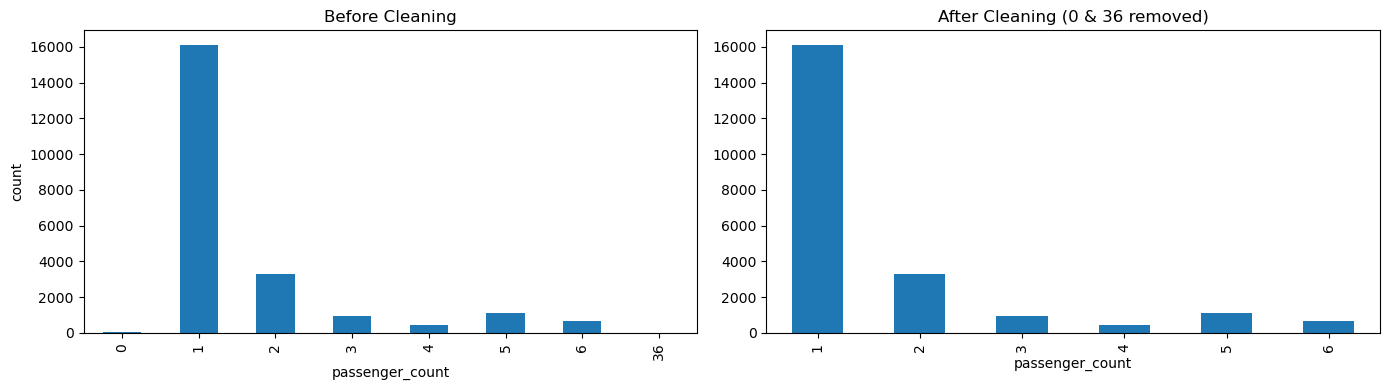

In [84]:
# 2) (분석 기준 통일) fare_amount 결측치 제거
df_raw = df_raw.dropna(subset=["fare_amount"])

# -----------------------------
# 제거 전: 데이터 상태 확인
# -----------------------------
print("📌 제거 전 데이터 크기:", df_raw.shape)

print("\n📌 제거 전 passenger_count 분포:")
before_counts = df_raw["passenger_count"].value_counts().sort_index()
print(before_counts)

# -----------------------------
# 제거: passenger_count = 0, 36 제거
# -----------------------------
df_clean = df_raw[(df_raw["passenger_count"] != 0) & (df_raw["passenger_count"] != 36)]

# -----------------------------
# 제거 후: 데이터 상태 확인
# -----------------------------
print("\n📌 제거 후 데이터 크기:", df_clean.shape)

print("\n📌 제거 후 passenger_count 분포:")
after_counts = df_clean["passenger_count"].value_counts().sort_index()
print(after_counts)

# -----------------------------
# 전/후 시각화 비교 (막대그래프 2개)
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 제거 전 그래프
before_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Before Cleaning")
axes[0].set_xlabel("passenger_count")
axes[0].set_ylabel("count")

# 제거 후 그래프
after_counts.plot(kind="bar", ax=axes[1])
axes[1].set_title("After Cleaning (0 & 36 removed)")
axes[1].set_xlabel("passenger_count")

plt.tight_layout()
plt.show()

<span style="background-color:#FFF3B0; color:#000; font-weight:bold;">
승객수 데이터 전처리 완료 <br>
그런데 운임비와 주행거리가 0인것도 이상하다.<br>   
0원을 받고 0만큼 이동한건 말이 안되니까 0값을 가진 데이터를 확인해보자 <br>그리고 거리와 운임은 비례하게 나올텐데 운임에서 튀는 두점이 보여 이것도 수상한데
</span>

trip_distance = 0 개수: 139
fare_amount = 0 개수: 6


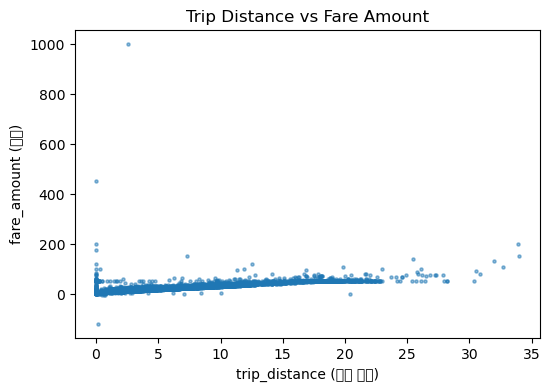

In [86]:
# 주행거리 0인 데이터 개수
print("trip_distance = 0 개수:", (df["trip_distance"] == 0).sum())

# 요금 0인 데이터 개수
print("fare_amount = 0 개수:", (df["fare_amount"] == 0).sum())

# 거리 vs 운임 산점도
plt.figure(figsize=(6, 4))
plt.scatter(df["trip_distance"], df["fare_amount"], s=5, alpha=0.5)

plt.xlabel("trip_distance (주행 거리)")
plt.ylabel("fare_amount (운임)")
plt.title("Trip Distance vs Fare Amount")

plt.show()

짧은 거리에 이상하게 높은 운임은 오류일 확률 높음. 제거 대상. 

In [ ]:

# 0거리 + 0요금 제거
# + 짧은 거리 & 고운임 이상치 제거


# (1) 제거 전 상태 확인
print("제거 전 데이터 크기:", df.shape)
print("trip_distance = 0 개수:", (df["trip_distance"] == 0).sum())
print("fare_amount = 0 개수:", (df["fare_amount"] == 0).sum())

# (2) 0거리 또는 0요금 제거
df = df[
    (df["trip_distance"] > 0) &
    (df["fare_amount"] > 0)
]

# (3) 짧은 거리 + 비정상적 고운임 제거
# 기준: trip_distance <= 1 AND fare_amount >= 200
df = df[
    ~(
        (df["trip_distance"] <= 1) &
        (df["fare_amount"] >= 200)
    )
]

# (4) 제거 후 상태 확인
print("\n제거 후 데이터 크기:", df.shape)
print("제거 후 trip_distance = 0 개수:", (df["trip_distance"] == 0).sum())
print("제거 후 fare_amount = 0 개수:", (df["fare_amount"] == 0).sum())


제거 전 데이터 크기: (20410, 9)
trip_distance = 0 개수: 139
fare_amount = 0 개수: 6

제거 후 데이터 크기: (20254, 9)
제거 후 trip_distance = 0 개수: 0
제거 후 fare_amount = 0 개수: 0


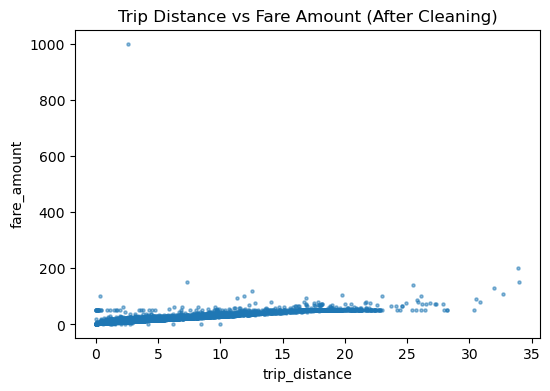

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(df["trip_distance"], df["fare_amount"], s=5, alpha=0.5)
plt.xlabel("trip_distance")
plt.ylabel("fare_amount")
plt.title("Trip Distance vs Fare Amount (After Cleaning)")
plt.show()


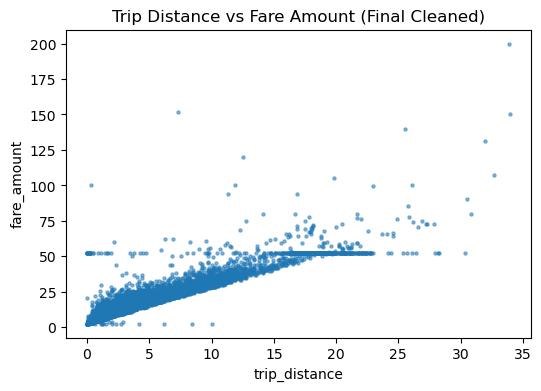

trip_distance = 0 개수: 0
fare_amount  = 0 개수: 0
passenger_count = 0 개수: 32


In [91]:
#점하나가 너무 튀어서 제거
df = df[df["fare_amount"] < 800]


plt.figure(figsize=(6, 4))
plt.scatter(df["trip_distance"], df["fare_amount"], s=5, alpha=0.5)
plt.xlabel("trip_distance")
plt.ylabel("fare_amount")
plt.title("Trip Distance vs Fare Amount (Final Cleaned)")
plt.show()

#0값도 없어졌는지 확인

print("trip_distance = 0 개수:", (df["trip_distance"] == 0).sum())
print("fare_amount  = 0 개수:", (df["fare_amount"] == 0).sum())
print("passenger_count = 0 개수:", (df["passenger_count"] == 0).sum())


In [92]:
#승객수 이상치와 결측치 제거가 안되었자나

# 제거 전 상태 확인
print("제거 전 passenger_count 분포:")
print(df["passenger_count"].value_counts().sort_index())
print("제거 전 데이터 크기:", df.shape)

# passenger_count = 0, 36 제거
df = df[
    (df["passenger_count"] != 0) &
    (df["passenger_count"] != 36)
]

# 제거 후 상태 확인
print("\n제거 후 passenger_count 분포:")
print(df["passenger_count"].value_counts().sort_index())
print("제거 후 데이터 크기:", df.shape)

# 안전 체크 (0값 남아있는지)
print("\n남아있는 passenger_count = 0 개수:",
      (df["passenger_count"] == 0).sum())
print("남아있는 passenger_count = 36 개수:",
      (df["passenger_count"] == 36).sum())

제거 전 passenger_count 분포:
passenger_count
0       32
1    15989
2     3284
3      948
Name: count, dtype: int64
제거 전 데이터 크기: (20253, 9)

제거 후 passenger_count 분포:
passenger_count
1    15989
2     3284
3      948
Name: count, dtype: int64
제거 후 데이터 크기: (20221, 9)

남아있는 passenger_count = 0 개수: 0
남아있는 passenger_count = 36 개수: 0



📌 [결측치 검증] 컬럼별 결측치 개수/비율
                       결측치 개수  결측치 비율(%)
passenger_name              0        0.0
tpep_pickup_datetime        0        0.0
tpep_dropoff_datetime       0        0.0
payment_method              0        0.0
passenger_count             0        0.0
trip_distance               0        0.0
fare_amount                 0        0.0
tip_amount                  0        0.0
tolls_amount                0        0.0


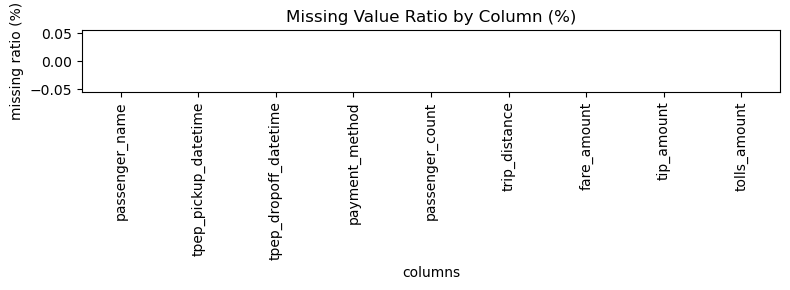


📌 [이상치 검증] 제거 규칙 위반 데이터가 남아있는지 체크
   → 아래 값들이 모두 0이면 '반영 완료'라고 보면 돼요.
passenger_count == 0                    : 0
passenger_count == 36                   : 0
trip_distance == 0                      : 0
fare_amount == 0                        : 0
(trip_distance<=1) & (fare_amount>=200) : 0
fare_amount >= 800                      : 0


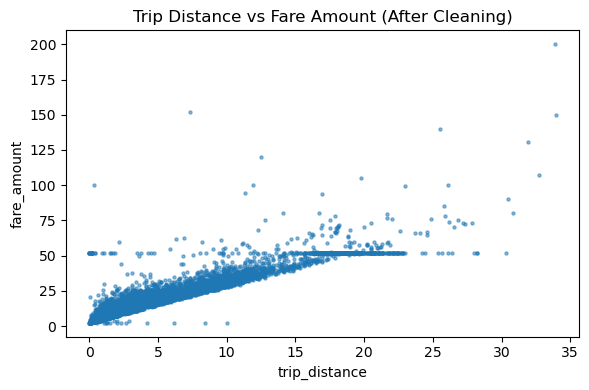

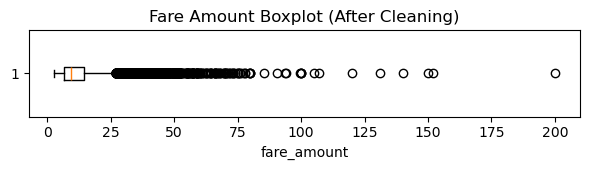

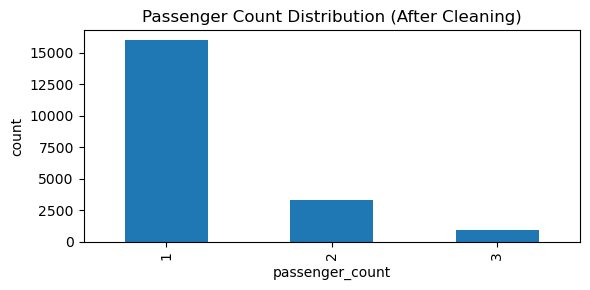

In [94]:
# 1) 결측치(Missing) 검증: 어디에, 몇 개, 비율(%)
# =========================================================
missing_count = df.isnull().sum()
missing_ratio = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "결측치 개수": missing_count,
    "결측치 비율(%)": missing_ratio
}).sort_values("결측치 비율(%)", ascending=False)

print("\n" + "="*60)
print("📌 [결측치 검증] 컬럼별 결측치 개수/비율")
print("="*60)
print(missing_summary)

# --- 시각화: 결측치 비율 바차트(0%는 거의 안 보일 수 있어요) ---
plt.figure(figsize=(8, 3))
missing_summary["결측치 비율(%)"].plot(kind="bar")
plt.title("Missing Value Ratio by Column (%)")
plt.xlabel("columns")
plt.ylabel("missing ratio (%)")
plt.tight_layout()
plt.show()

# =========================================================
# 2) 이상치(Outlier) 검증: 우리가 제거하기로 한 조건들이 남아있는지
#    ✅ 우리가 합의했던 규칙(필요하면 숫자 기준을 바꾸면 됨)
# =========================================================

# --- 우리가 제거하기로 한 기준(지금까지 대화 기준) ---
# 1) passenger_count: 0 제거, 36 제거
# 2) trip_distance: 0 제거
# 3) fare_amount: 0 제거
# 4) 짧은 거리인데 고운임 제거: trip_distance <= 1 AND fare_amount >= 200
# 5) 운임 극단값(단일 점) 제거: fare_amount >= 800 (네가 적용했을 수도/아닐 수도 있어서 검사만 함)

checks = {}

# (A) passenger_count 0/36 남아있는지
if "passenger_count" in df.columns:
    checks["passenger_count == 0"] = int((df["passenger_count"] == 0).sum())
    checks["passenger_count == 36"] = int((df["passenger_count"] == 36).sum())
else:
    checks["passenger_count 컬럼 없음"] = None

# (B) trip_distance/fare_amount 0 남아있는지
if "trip_distance" in df.columns:
    checks["trip_distance == 0"] = int((df["trip_distance"] == 0).sum())
else:
    checks["trip_distance 컬럼 없음"] = None

if "fare_amount" in df.columns:
    checks["fare_amount == 0"] = int((df["fare_amount"] == 0).sum())
else:
    checks["fare_amount 컬럼 없음"] = None

# (C) 짧은 거리 + 고운임(우리가 제거하기로 한 “수상한 점들”)
if ("trip_distance" in df.columns) and ("fare_amount" in df.columns):
    checks["(trip_distance<=1) & (fare_amount>=200)"] = int(
        ((df["trip_distance"] <= 1) & (df["fare_amount"] >= 200)).sum()
    )

    # (D) 운임 극단값(단일 점) 후보
    checks["fare_amount >= 800"] = int((df["fare_amount"] >= 800).sum())

print("\n" + "="*60)
print("📌 [이상치 검증] 제거 규칙 위반 데이터가 남아있는지 체크")
print("   → 아래 값들이 모두 0이면 '반영 완료'라고 보면 돼요.")
print("="*60)

for k, v in checks.items():
    print(f"{k:40s}: {v}")

# =========================================================
# 3) 시각화로 “정제 결과” 눈으로 확인
# =========================================================

# (1) 거리 vs 요금 산점도 (정제 후)
if ("trip_distance" in df.columns) and ("fare_amount" in df.columns):
    plt.figure(figsize=(6, 4))
    plt.scatter(df["trip_distance"], df["fare_amount"], s=5, alpha=0.5)
    plt.title("Trip Distance vs Fare Amount (After Cleaning)")
    plt.xlabel("trip_distance")
    plt.ylabel("fare_amount")
    plt.tight_layout()
    plt.show()

# (2) fare_amount 분포: 박스플롯(이상치가 남아있으면 점/수염이 튈 수 있음)
if "fare_amount" in df.columns:
    plt.figure(figsize=(6, 1.8))
    plt.boxplot(df["fare_amount"].dropna(), vert=False)
    plt.title("Fare Amount Boxplot (After Cleaning)")
    plt.xlabel("fare_amount")
    plt.tight_layout()
    plt.show()

# (3) passenger_count 분포 막대그래프(0,36 제거됐는지 직관적으로 확인)
if "passenger_count" in df.columns:
    plt.figure(figsize=(6, 3))
    df["passenger_count"].value_counts().sort_index().plot(kind="bar")
    plt.title("Passenger Count Distribution (After Cleaning)")
    plt.xlabel("passenger_count")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

<span style="background-color:#FFF3B0; color:#000; font-weight:bold;">
정제된 숫자형 데이터를 다시 저장하고 스캐터 플롯 시각화를 다시 보자.   </span> 
  
df → 중간 작업용  
final_df → 이상치/결측치 전부 반영된 최종 데이터  


In [95]:
# ============================================
# 정제 완료된 데이터를 새 변수로 저장
# ============================================

final_df = df.copy()

print("final_df 데이터 크기:", final_df.shape)


final_df 데이터 크기: (20221, 9)


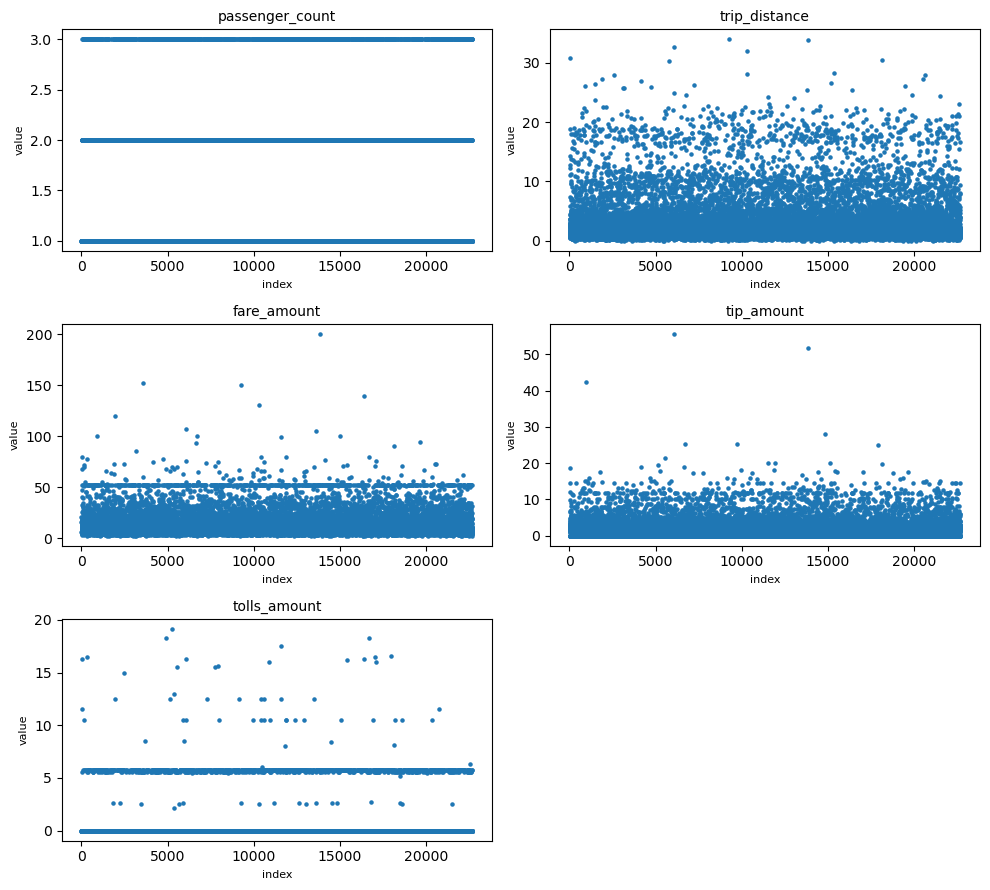

In [102]:
import numpy as np

numeric_cols = final_df.select_dtypes(include=["int64", "float64"]).columns

n_cols = 2
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

plt.figure(figsize=(10, 3 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.scatter(final_df.index, final_df[col], s=5)
    plt.title(col, fontsize=10)
    plt.xlabel("index", fontsize=8)
    plt.ylabel("value", fontsize=8)

plt.tight_layout()
plt.show()

이제 승하차 시간을 분리해보자

In [118]:
final_df.columns = final_df.columns.str.strip()

# ============================================
# 1) datetime 컬럼이 있는지 먼저 확인
#    (없으면 에러 대신 안내 메시지)
# ============================================
pickup_col = "tpep_pickup_datetime"
dropoff_col = "tpep_dropoff_datetime"

print("✅ 현재 final_df에 pickup 컬럼 있나?", pickup_col in final_df.columns)
print("✅ 현재 final_df에 dropoff 컬럼 있나?", dropoff_col in final_df.columns)

# ============================================
# 2) 컬럼이 있을 때만 변환 + 분해 + 삭제 실행
# ============================================
if (pickup_col in final_df.columns) and (dropoff_col in final_df.columns):

    # (1) 문자열 -> datetime 변환
    final_df[pickup_col] = pd.to_datetime(final_df[pickup_col], errors="coerce")
    final_df[dropoff_col] = pd.to_datetime(final_df[dropoff_col], errors="coerce")

    # (2) pickup 시간 분해
    final_df["pickup_year"] = final_df[pickup_col].dt.year
    final_df["pickup_month"] = final_df[pickup_col].dt.month
    final_df["pickup_day"] = final_df[pickup_col].dt.day
    final_df["pickup_hour"] = final_df[pickup_col].dt.hour
    final_df["pickup_weekday"] = final_df[pickup_col].dt.weekday
    final_df["is_weekend"] = final_df["pickup_weekday"].isin([5, 6]).astype(int)

    # (3) (선택) dropoff 시간에서 시간만 분해
    final_df["dropoff_hour"] = final_df[dropoff_col].dt.hour

    # (4) 원본 datetime 컬럼 삭제 (덮어쓰기)
    final_df.drop(columns=[pickup_col, dropoff_col], inplace=True)

    print("\n🎉 시간 분해 + 원본 datetime 컬럼 삭제 완료!")

else:
    print("\n⚠️ 이미 datetime 컬럼을 삭제했거나 컬럼명이 달라요.")
    print("final_df.columns에서 pickup/dropoff 관련 컬럼명을 다시 확인해보세요:")
    print([c for c in final_df.columns if "pickup" in c.lower() or "dropoff" in c.lower()])

# ============================================
# 3) 최종 확인 (시간 분해 컬럼이 잘 들어갔는지)
# ============================================
check_cols = ["pickup_year","pickup_month","pickup_day","pickup_hour","pickup_weekday","is_weekend","dropoff_hour"]
print("\n✅ 생성된 시간 컬럼 존재 여부:")
print({c: (c in final_df.columns) for c in check_cols})

print("\n✅ 시간 컬럼 샘플 5개:")
print(final_df[check_cols].head())

display(final_df.head())

✅ 현재 final_df에 pickup 컬럼 있나? False
✅ 현재 final_df에 dropoff 컬럼 있나? False

⚠️ 이미 datetime 컬럼을 삭제했거나 컬럼명이 달라요.
final_df.columns에서 pickup/dropoff 관련 컬럼명을 다시 확인해보세요:
['pep_pickup_datetime', 'pickup_year', 'pickup_month', 'pickup_day', 'pickup_hour', 'pickup_weekday', 'dropoff_hour']

✅ 생성된 시간 컬럼 존재 여부:
{'pickup_year': True, 'pickup_month': True, 'pickup_day': True, 'pickup_hour': True, 'pickup_weekday': True, 'is_weekend': True, 'dropoff_hour': True}

✅ 시간 컬럼 샘플 5개:
   pickup_year  pickup_month  pickup_day  pickup_hour  pickup_weekday  \
1         2017             4          11           14               1   
2         2017            12          15            7               4   
3         2017             5           7           13               6   
4         2017             4          15           23               5   
6         2017             5           3           19               2   

   is_weekend  dropoff_hour  
1           0            15  
2           0             7  
3     

,passenger_name,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,pep_pickup_datetime,pickup_year,pickup_month,pickup_day,pickup_hour,pickup_weekday,is_weekend,dropoff_hour
1,Michelle Foster,Debit Card,1,1.80,16.0,4.00,0.0,2017-04-11 14:53:28,2017,4,11,14,1,0,15
2,Tina Combs,Debit Card,1,1.00,6.5,1.45,0.0,2017-12-15 07:26:56,2017,12,15,7,4,0,7
3,Anthony Ray,Cash,1,3.70,20.5,6.39,0.0,2017-05-07 13:17:59,2017,5,7,13,6,1,13
4,Brianna Johnson,Debit Card,1,4.37,16.5,0.00,0.0,2017-04-15 23:32:20,2017,4,15,23,5,1,23
6,Tonya Moreno,Cash,1,12.83,47.5,9.86,0.0,2017-05-03 19:04:09,2017,5,3,19,2,0,20


In [127]:
# final_df 컬럼 전체 확인 (가장 확실)
print(final_df.columns.tolist())

# pickup 관련 컬럼만 필터해서 보기 (눈으로 찾기 쉬움)
print([c for c in final_df.columns if "pickup" in c.lower()])

# dropoff 관련 컬럼도 같이 보기
print([c for c in final_df.columns if "dropoff" in c.lower()])

display(final_df)

# ============================================
# 시간(hour) + 분(minute) + 초(second)
# → 하루 기준 초 단위 컬럼 생성
# ============================================

final_df["pickup_time_seconds"] = (
    final_df["pickup_hour"] * 3600 +
    final_df["pickup_minute"] * 60 +
    final_df["pickup_second"]
)

# 결과 확인
print("✅ pickup_time_seconds 생성 확인:")
print(
    final_df[["pickup_hour", "pickup_minute", "pickup_second", "pickup_time_seconds"]]
    .head()
)


['passenger_name', 'payment_method', 'passenger_count', 'trip_distance', 'fare_amount', 'tip_amount', 'tolls_amount', 'pickup_year', 'pickup_month', 'pickup_day', 'pickup_hour', 'pickup_weekday', 'is_weekend', 'dropoff_hour', 'pickup_minute', 'pickup_second']
['pickup_year', 'pickup_month', 'pickup_day', 'pickup_hour', 'pickup_weekday', 'pickup_minute', 'pickup_second']
['dropoff_hour']


,passenger_name,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,pickup_year,pickup_month,pickup_day,pickup_hour,pickup_weekday,is_weekend,dropoff_hour,pickup_minute,pickup_second
1,Michelle Foster,Debit Card,1,1.80,16.0,4.00,0.00,2017,4,11,14,1,0,15,53,28
2,Tina Combs,Debit Card,1,1.00,6.5,1.45,0.00,2017,12,15,7,4,0,7,26,56
3,Anthony Ray,Cash,1,3.70,20.5,6.39,0.00,2017,5,7,13,6,1,13,17,59
4,Brianna Johnson,Debit Card,1,4.37,16.5,0.00,0.00,2017,4,15,23,5,1,23,32,20
6,Tonya Moreno,Cash,1,12.83,47.5,9.86,0.00,2017,5,3,19,2,0,20,4,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22696,Austin Johnson,Cash,3,0.61,4.0,0.00,0.00,2017,2,24,17,4,0,17,37,23
22697,Monique Williams,Cash,1,16.71,52.0,14.64,5.76,2017,8,6,16,6,1,17,43,59
22698,Drew Graves,Debit Card,1,0.42,4.5,0.00,0.00,2017,9,4,14,0,0,14,54,14
22699,Jonathan Copeland,Debit Card,1,2.36,10.5,1.70,0.00,2017,7,15,12,5,1,13,56,30


✅ pickup_time_seconds 생성 확인:
   pickup_hour  pickup_minute  pickup_second  pickup_time_seconds
1           14             53             28                53608
2            7             26             56                26816
3           13             17             59                47879
4           23             32             20                84740
6           19              4              9                68649


In [129]:
# dropoff 관련 컬럼이 남아있는지 확인
print([c for c in final_df.columns if "dropoff" in c.lower()])
print([c for c in final_df.columns if "pickup" in c.lower()])


['dropoff_hour']
['pickup_year', 'pickup_month', 'pickup_day', 'pickup_hour', 'pickup_weekday', 'pickup_minute', 'pickup_second', 'pickup_time_seconds']


In [130]:
import pandas as pd

# ============================================
# 1) 원본 CSV 다시 읽기 (파일 수정 X, 읽기만!)
# ============================================
raw = pd.read_csv("../00_Dataset/trip.csv")
raw.columns = raw.columns.str.strip()  # 혹시 컬럼명 공백 있으면 제거

# ============================================
# 2) 원본에서 pickup/dropoff datetime 컬럼 자동 찾기
#    (pep/tpep/lpep 등 이름이 달라도 잡히게)
# ============================================
pickup_candidates = [c for c in raw.columns if ("pickup" in c.lower() and "datetime" in c.lower())]
dropoff_candidates = [c for c in raw.columns if ("dropoff" in c.lower() and "datetime" in c.lower())]

print("✅ raw pickup 후보:", pickup_candidates)
print("✅ raw dropoff 후보:", dropoff_candidates)

if len(pickup_candidates) == 0 or len(dropoff_candidates) == 0:
    raise ValueError("원본 데이터에서 pickup/dropoff datetime 컬럼을 못 찾았어요!")

pickup_col = pickup_candidates[0]
dropoff_col = dropoff_candidates[0]

# ============================================
# 3) datetime 변환 + 탑승시간(초) 계산
#    (하차 - 승차) → 초 단위
# ============================================
raw[pickup_col] = pd.to_datetime(raw[pickup_col], errors="coerce")
raw[dropoff_col] = pd.to_datetime(raw[dropoff_col], errors="coerce")

raw["trip_duration_seconds"] = (raw[dropoff_col] - raw[pickup_col]).dt.total_seconds()

# ============================================
# 4) final_df에 duration 붙이기 (⭐ 인덱스 기준)
#    final_df는 정제하면서 행이 줄었으니,
#    final_df의 index에 해당하는 raw 행에서 duration만 가져와 붙임
# ============================================
final_df["trip_duration_seconds"] = raw.loc[final_df.index, "trip_duration_seconds"].values

# ============================================
# 5) 잘 붙었는지 확인
# ============================================
print("\n✅ final_df에 trip_duration_seconds 추가 완료!")
print(final_df[["trip_duration_seconds"]].head())

print("\n📌 trip_duration_seconds 결측치 개수:", final_df["trip_duration_seconds"].isnull().sum())
print("📌 음수(이상) duration 개수:", (final_df["trip_duration_seconds"] < 0).sum())
print("📌 0초 duration 개수:", (final_df["trip_duration_seconds"] == 0).sum())


✅ raw pickup 후보: ['tpep_pickup_datetime']
✅ raw dropoff 후보: ['tpep_dropoff_datetime']

✅ final_df에 trip_duration_seconds 추가 완료!
   trip_duration_seconds
1                 1590.0
2                  432.0
3                 1815.0
4                 1003.0
6                 3578.0

📌 trip_duration_seconds 결측치 개수: 0
📌 음수(이상) duration 개수: 1
📌 0초 duration 개수: 0


In [133]:
import pandas as pd

# ============================================
# 1) 원본 CSV 읽기 (파일 수정 X)
# ============================================
raw = pd.read_csv("../00_Dataset/trip.csv")
raw.columns = raw.columns.str.strip()

# ============================================
# 2) pickup / dropoff datetime 컬럼 자동 찾기
# ============================================
pickup_col = [c for c in raw.columns if "pickup" in c.lower() and "datetime" in c.lower()][0]
dropoff_col = [c for c in raw.columns if "dropoff" in c.lower() and "datetime" in c.lower()][0]

# ============================================
# 3) datetime 변환
# ============================================
raw[pickup_col] = pd.to_datetime(raw[pickup_col], errors="coerce")
raw[dropoff_col] = pd.to_datetime(raw[dropoff_col], errors="coerce")

# ============================================
# 4) 탑승 시간(초) 계산
# ============================================
raw["trip_duration_seconds"] = (
    raw[dropoff_col] - raw[pickup_col]
).dt.total_seconds()

# ============================================
# 5) final_df에 컬럼 추가 (⭐ 제거 없음)
# ============================================
final_df["trip_duration_seconds"] = raw.loc[
    final_df.index, "trip_duration_seconds"
].values

# ============================================
# 6) 확인
# ============================================
print("✅ trip_duration_seconds 컬럼 추가 완료!")
print(final_df["trip_duration_seconds"].head())

print("\n📌 기초 통계:")
print(final_df["trip_duration_seconds"].describe())

display(final_df)


✅ trip_duration_seconds 컬럼 추가 완료!
1    1590.0
2     432.0
3    1815.0
4    1003.0
6    3578.0
Name: trip_duration_seconds, dtype: float64

📌 기초 통계:
count    20184.000000
mean       863.917162
std        691.913528
min          1.000000
25%        403.000000
50%        675.000000
75%       1101.000000
max       9559.000000
Name: trip_duration_seconds, dtype: float64


,passenger_name,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,pickup_year,pickup_month,pickup_day,pickup_hour,pickup_weekday,is_weekend,dropoff_hour,pickup_minute,pickup_second,pickup_time_seconds,trip_duration_seconds
1,Michelle Foster,Debit Card,1,1.80,16.0,4.00,0.00,2017,4,11,14,1,0,15,53,28,53608,1590.0
2,Tina Combs,Debit Card,1,1.00,6.5,1.45,0.00,2017,12,15,7,4,0,7,26,56,26816,432.0
3,Anthony Ray,Cash,1,3.70,20.5,6.39,0.00,2017,5,7,13,6,1,13,17,59,47879,1815.0
4,Brianna Johnson,Debit Card,1,4.37,16.5,0.00,0.00,2017,4,15,23,5,1,23,32,20,84740,1003.0
6,Tonya Moreno,Cash,1,12.83,47.5,9.86,0.00,2017,5,3,19,2,0,20,4,9,68649,3578.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22696,Austin Johnson,Cash,3,0.61,4.0,0.00,0.00,2017,2,24,17,4,0,17,37,23,63443,196.0
22697,Monique Williams,Cash,1,16.71,52.0,14.64,5.76,2017,8,6,16,6,1,17,43,59,60239,2448.0
22698,Drew Graves,Debit Card,1,0.42,4.5,0.00,0.00,2017,9,4,14,0,0,14,54,14,53654,248.0
22699,Jonathan Copeland,Debit Card,1,2.36,10.5,1.70,0.00,2017,7,15,12,5,1,13,56,30,46590,716.0


In [134]:
# ============================================
# 필요 없는 컬럼 제거
# ============================================

final_df.drop(
    columns=["pickup_year", "pickup_time_seconds"],
    inplace=True
)

# 결과 확인
print("✅ 컬럼 제거 완료!")
print(final_df.columns.tolist())
final_df

✅ 컬럼 제거 완료!
['passenger_name', 'payment_method', 'passenger_count', 'trip_distance', 'fare_amount', 'tip_amount', 'tolls_amount', 'pickup_month', 'pickup_day', 'pickup_hour', 'pickup_weekday', 'is_weekend', 'dropoff_hour', 'pickup_minute', 'pickup_second', 'trip_duration_seconds']


,passenger_name,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,pickup_month,pickup_day,pickup_hour,pickup_weekday,is_weekend,dropoff_hour,pickup_minute,pickup_second,trip_duration_seconds
1,Michelle Foster,Debit Card,1,1.80,16.0,4.00,0.00,4,11,14,1,0,15,53,28,1590.0
2,Tina Combs,Debit Card,1,1.00,6.5,1.45,0.00,12,15,7,4,0,7,26,56,432.0
3,Anthony Ray,Cash,1,3.70,20.5,6.39,0.00,5,7,13,6,1,13,17,59,1815.0
4,Brianna Johnson,Debit Card,1,4.37,16.5,0.00,0.00,4,15,23,5,1,23,32,20,1003.0
6,Tonya Moreno,Cash,1,12.83,47.5,9.86,0.00,5,3,19,2,0,20,4,9,3578.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22696,Austin Johnson,Cash,3,0.61,4.0,0.00,0.00,2,24,17,4,0,17,37,23,196.0
22697,Monique Williams,Cash,1,16.71,52.0,14.64,5.76,8,6,16,6,1,17,43,59,2448.0
22698,Drew Graves,Debit Card,1,0.42,4.5,0.00,0.00,9,4,14,0,0,14,54,14,248.0
22699,Jonathan Copeland,Debit Card,1,2.36,10.5,1.70,0.00,7,15,12,5,1,13,56,30,716.0


In [138]:
# 컬럼명 전체 확인
print(final_df.columns.tolist())

# payment 관련 컬럼이 뭐가 있는지 확인
print([c for c in final_df.columns if "payment" in c.lower()])


['passenger_name', 'passenger_count', 'trip_distance', 'fare_amount', 'tip_amount', 'tolls_amount', 'pickup_month', 'pickup_day', 'pickup_hour', 'pickup_weekday', 'is_weekend', 'dropoff_hour', 'pickup_minute', 'pickup_second', 'trip_duration_seconds']
[]


In [140]:
# 1) 원본 CSV에서 결제 컬럼 찾기 (파일 수정 X)
# ============================================
raw = pd.read_csv("../00_Dataset/trip.csv")
raw.columns = raw.columns.str.strip()

pay_candidates = [c for c in raw.columns if "payment" in c.lower()]
print("✅ 원본(raw) 결제 컬럼 후보:", pay_candidates)

if len(pay_candidates) == 0:
    raise ValueError("원본 trip.csv에도 payment 관련 컬럼이 없어요. 컬럼명을 다시 확인해야 해요!")

pay_col = pay_candidates[0]  # 보통 payment_method
print("🎯 사용할 결제 컬럼:", pay_col)

# ============================================
# 2) final_df에 결제 컬럼 다시 붙이기 (인덱스 기준)
#    - final_df는 정제로 행이 줄었으므로
#      final_df.index에 해당하는 raw 행만 가져와 붙임
# ============================================
final_df[pay_col] = raw.loc[final_df.index, pay_col].values

# ============================================
# 3) Card / Cash로 새 컬럼 만들기
# ============================================
final_df["payment_type_simple"] = final_df[pay_col].astype(str).str.lower().apply(
    lambda x: "Card" if ("credit" in x or "debit" in x or "card" in x) else "Cash"
)

# ============================================
# 4) 기존 3분류 결제 컬럼 삭제
# ============================================
final_df.drop(columns=[pay_col], inplace=True)

# ============================================
# 5) 확인
# ============================================
print("\n✅ payment_type_simple 생성 완료!")
print(final_df["payment_type_simple"].value_counts())

print("\n📌 최종 컬럼 목록:")
print(final_df.columns.tolist())

display(final_df)

✅ 원본(raw) 결제 컬럼 후보: ['payment_method']
🎯 사용할 결제 컬럼: payment_method

✅ payment_type_simple 생성 완료!
payment_type_simple
Card    10241
Cash     9943
Name: count, dtype: int64

📌 최종 컬럼 목록:
['passenger_name', 'passenger_count', 'trip_distance', 'fare_amount', 'tip_amount', 'tolls_amount', 'pickup_month', 'pickup_day', 'pickup_hour', 'pickup_weekday', 'is_weekend', 'dropoff_hour', 'pickup_minute', 'pickup_second', 'trip_duration_seconds', 'payment_type_simple']


,passenger_name,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,pickup_month,pickup_day,pickup_hour,pickup_weekday,is_weekend,dropoff_hour,pickup_minute,pickup_second,trip_duration_seconds,payment_type_simple
1,Michelle Foster,1,1.80,16.0,4.00,0.00,4,11,14,1,0,15,53,28,1590.0,Card
2,Tina Combs,1,1.00,6.5,1.45,0.00,12,15,7,4,0,7,26,56,432.0,Card
3,Anthony Ray,1,3.70,20.5,6.39,0.00,5,7,13,6,1,13,17,59,1815.0,Cash
4,Brianna Johnson,1,4.37,16.5,0.00,0.00,4,15,23,5,1,23,32,20,1003.0,Card
6,Tonya Moreno,1,12.83,47.5,9.86,0.00,5,3,19,2,0,20,4,9,3578.0,Cash
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22696,Austin Johnson,3,0.61,4.0,0.00,0.00,2,24,17,4,0,17,37,23,196.0,Cash
22697,Monique Williams,1,16.71,52.0,14.64,5.76,8,6,16,6,1,17,43,59,2448.0,Cash
22698,Drew Graves,1,0.42,4.5,0.00,0.00,9,4,14,0,0,14,54,14,248.0,Card
22699,Jonathan Copeland,1,2.36,10.5,1.70,0.00,7,15,12,5,1,13,56,30,716.0,Card


In [142]:
# 결제수단 숫자형 컬럼 추가 (기존 범주형 유지)
# Card = 1, Cash = 0
# ============================================

final_df["payment_type_numeric"] = final_df["payment_type_simple"].map(
    {"Card": 1, "Cash": 0}
)

# 결과 확인
print("✅ payment_type_numeric 생성 완료!")
print(
    final_df[["payment_type_simple", "payment_type_numeric"]]
    .value_counts()
)
display(final_df)

✅ payment_type_numeric 생성 완료!
payment_type_simple  payment_type_numeric
Card                 1                       10241
Cash                 0                        9943
Name: count, dtype: int64


,passenger_name,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,pickup_month,pickup_day,pickup_hour,pickup_weekday,is_weekend,dropoff_hour,pickup_minute,pickup_second,trip_duration_seconds,payment_type_simple,payment_type_numeric
1,Michelle Foster,1,1.80,16.0,4.00,0.00,4,11,14,1,0,15,53,28,1590.0,Card,1
2,Tina Combs,1,1.00,6.5,1.45,0.00,12,15,7,4,0,7,26,56,432.0,Card,1
3,Anthony Ray,1,3.70,20.5,6.39,0.00,5,7,13,6,1,13,17,59,1815.0,Cash,0
4,Brianna Johnson,1,4.37,16.5,0.00,0.00,4,15,23,5,1,23,32,20,1003.0,Card,1
6,Tonya Moreno,1,12.83,47.5,9.86,0.00,5,3,19,2,0,20,4,9,3578.0,Cash,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22696,Austin Johnson,3,0.61,4.0,0.00,0.00,2,24,17,4,0,17,37,23,196.0,Cash,0
22697,Monique Williams,1,16.71,52.0,14.64,5.76,8,6,16,6,1,17,43,59,2448.0,Cash,0
22698,Drew Graves,1,0.42,4.5,0.00,0.00,9,4,14,0,0,14,54,14,248.0,Card,1
22699,Jonathan Copeland,1,2.36,10.5,1.70,0.00,7,15,12,5,1,13,56,30,716.0,Card,1


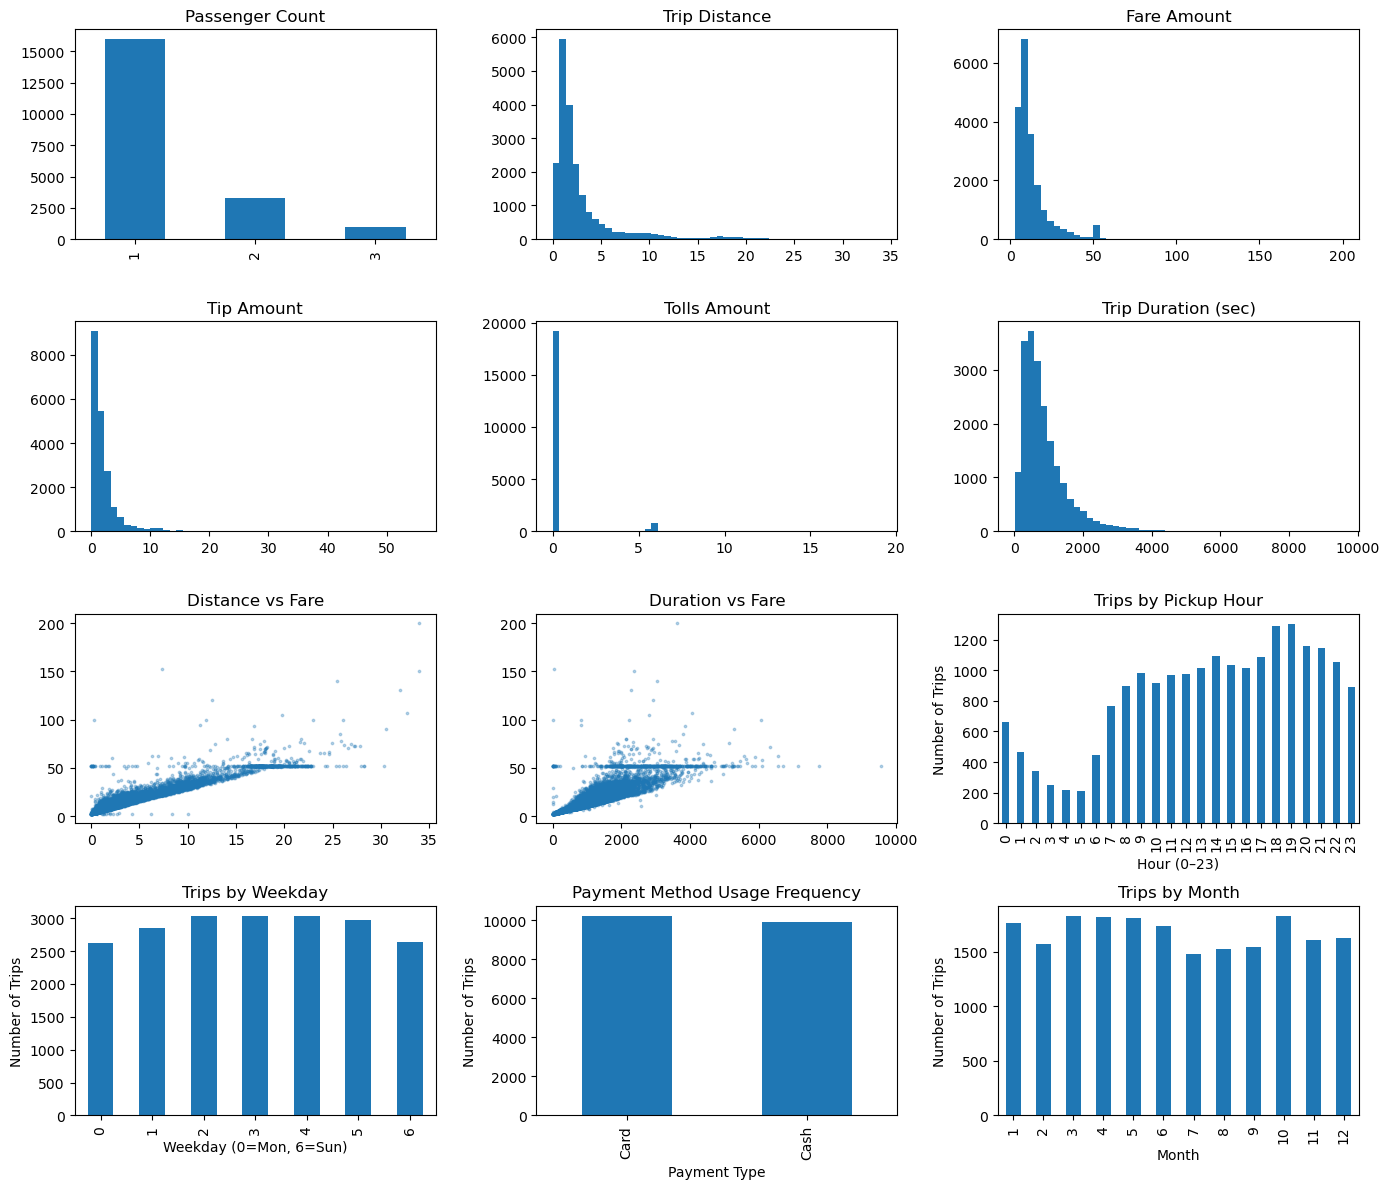

In [154]:
import matplotlib.pyplot as plt

# ============================================
# 대시보드처럼 한 화면에 모아보기 (작게)
# ============================================

fig, axes = plt.subplots(4, 3, figsize=(14, 12))  # (행, 열), 화면 크기
axes = axes.ravel()  # 2차원 배열을 1차원처럼 쓰기

# 1) passenger_count
final_df["passenger_count"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Passenger Count")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

# 2) trip_distance
axes[1].hist(final_df["trip_distance"], bins=50)
axes[1].set_title("Trip Distance")

# 3) fare_amount
axes[2].hist(final_df["fare_amount"], bins=50)
axes[2].set_title("Fare Amount")

# 4) tip_amount
axes[3].hist(final_df["tip_amount"], bins=50)
axes[3].set_title("Tip Amount")

# 5) tolls_amount
axes[4].hist(final_df["tolls_amount"], bins=50)
axes[4].set_title("Tolls Amount")

# 6) duration
axes[5].hist(final_df["trip_duration_seconds"], bins=50)
axes[5].set_title("Trip Duration (sec)")

# 7) distance vs fare
axes[6].scatter(final_df["trip_distance"], final_df["fare_amount"], s=3, alpha=0.3)
axes[6].set_title("Distance vs Fare")

# 8) duration vs fare
axes[7].scatter(final_df["trip_duration_seconds"], final_df["fare_amount"], s=3, alpha=0.3)
axes[7].set_title("Duration vs Fare")

# 9) 시간대별 이용륭
final_df["pickup_hour"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[8]
)

axes[8].set_title("Trips by Pickup Hour")
axes[8].set_xlabel("Hour (0–23)")
axes[8].set_ylabel("Number of Trips")

# 10) 요일별 이용륭
final_df["pickup_weekday"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[9]
)

axes[9].set_title("Trips by Weekday")
axes[9].set_xlabel("Weekday (0=Mon, 6=Sun)")
axes[9].set_ylabel("Number of Trips")

# 11) 현금과 카드 사용율
final_df["payment_type_simple"].value_counts().plot(
    kind="bar",
    ax=axes[10]
)

axes[10].set_title("Payment Method Usage Frequency")
axes[10].set_xlabel("Payment Type")
axes[10].set_ylabel("Number of Trips")

# 12) 월별 이용률
final_df["pickup_month"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[11]
)

axes[11].set_title("Trips by Month")
axes[11].set_xlabel("Month")
axes[11].set_ylabel("Number of Trips")
# 12) 빈 칸(남는 축 숨기기)
# axes[11].axis("off")

# 여백 자동 정리 (한눈에 보기 좋게)
plt.tight_layout()
plt.show()


# 📊 택시 이용 데이터 대시보드 분석 리포트

## 1. 분석 목적
본 분석은 택시 이용 데이터를 기반으로  
**이용 패턴과 요금 구조를 종합적으로 이해**하고,  
향후 **택시 요금 예측 및 수요 분석을 위한 기초 인사이트 도출**을 목적으로 한다.  

이를 위해 승객 수, 이동 거리, 요금, 탑승 시간, 시간대, 요일, 월별 이용률,
결제 수단 등 다양한 변수를 시각화하여 데이터의 전반적인 특성을 탐색하였다.

---

## 2. 주요 변수 분포 분석

### 2.1 승객 수 분포 (Passenger Count)
- 택시 이용의 대부분은 **1인 승객**이 차지하고 있다.
- 2인 및 3인 이상의 이용은 상대적으로 적은 비중을 보인다.
- 이는 택시가 주로 **개인 단위 이동 수단**으로 활용되고 있음을 시사한다.

---

### 2.2 이동 거리 분포 (Trip Distance)
- 이동 거리는 **짧은 거리 구간에 강하게 집중**되어 있다.
- 일부 장거리 이동이 존재하며, 전체 분포는 **우측으로 긴 꼬리를 가진 형태**를 보인다.
- 이는 도심 내 단거리 이동 중심의 택시 이용 패턴을 반영한다.

---

### 2.3 요금 분포 (Fare Amount)
- 요금 역시 낮은 금액대에 집중되어 있으며,
  이동 거리 분포와 유사한 형태를 나타낸다.
- 일부 고액 요금은 장거리 이동 또는 추가 요금 발생 사례로 해석할 수 있다.
- 전반적으로 요금은 **거리 기반 요금 구조**를 따르고 있음을 확인할 수 있다.

---

### 2.4 팁 및 통행료 분포 (Tip / Tolls Amount)
- 팁 금액은 대부분 0 또는 매우 낮은 수준에 집중되어 있다.
- 통행료는 거의 발생하지 않으며,
  특정 경우에만 제한적으로 발생하는 패턴을 보인다.
- 두 변수 모두 요금에 부가적으로 영향을 미치지만,
  **모든 이용에서 발생하는 요소는 아니다**.

---

### 2.5 탑승 시간 분포 (Trip Duration)
- 탑승 시간은 비교적 짧은 구간에 집중되어 있으며,
  일부 장시간 이동 사례가 존재한다.
- 이동 거리와 유사한 분포 형태를 보이며,
  요금과의 관계가 예상된다.

---

## 3. 변수 간 관계 분석

### 3.1 이동 거리 vs 요금
- 이동 거리가 증가할수록 요금이 **명확하게 증가하는 양의 관계**가 관찰된다.
- 산점도 상에서 거의 선형에 가까운 패턴이 나타나,
  이동 거리는 요금을 설명하는 **가장 핵심적인 변수**임을 확인할 수 있다.

---

### 3.2 탑승 시간 vs 요금
- 탑승 시간 역시 요금과 **양의 상관관계**를 보인다.
- 동일한 거리라도 교통 상황에 따라 탑승 시간이 길어질 경우
  요금이 증가하는 경향이 나타난다.
- 이는 요금 예측 시 **이동 거리와 탑승 시간을 함께 고려해야 함**을 시사한다.

---

## 4. 이용 패턴 분석 (이용률 중심)

### 4.1 시간대별 이용률 (Trips by Pickup Hour)
- 택시 이용은 **특정 시간대에 집중되는 피크 현상**을 보인다.
- 특히 낮 시간대부터 저녁 시간대까지 이용률이 높게 나타나며,
  이는 출퇴근 및 일상 이동 수요와 밀접한 관련이 있다.
- 심야 및 새벽 시간대에는 상대적으로 이용률이 낮다.

---

### 4.2 요일별 이용률 (Trips by Weekday)
- 요일별 이용률은 큰 차이는 없으나,
  **평일에 비교적 안정적인 이용 패턴**을 보인다.
- 주말에는 일부 변동이 나타나며,
  이는 여가 및 비일상적 이동 수요가 반영된 결과로 해석할 수 있다.

---

### 4.3 월별 이용률 (Trips by Month)
- 월별 이용 건수는 비교적 고르게 분포되어 있으나,
  일부 월에서 이용이 증가하거나 감소하는 경향이 관찰된다.
- 이는 계절적 요인이나 시기별 이동 수요 변화가
  택시 이용률에 영향을 미칠 가능성을 시사한다.

---

## 5. 결제 수단 이용 패턴

### 5.1 결제 수단별 이용 빈도
- 카드(Card)와 현금(Cash) 결제 모두 높은 이용 빈도를 보인다.
- 카드 결제가 다소 높은 비중을 차지하며,
  이는 결제 방식의 디지털화 및 편의성 선호 경향을 반영한다.
- 결제 수단은 요금 차이보다는 **이용 행태를 설명하는 변수**로 해석하는 것이 적절하다.

---

## 6. 종합 해석 및 시사점
- 택시 요금은 **이동 거리와 탑승 시간**이 가장 중요한 결정 요인이다.
- 시간대, 요일, 월별 이용률 분석을 통해
  택시 이용에는 뚜렷한 **생활 패턴 및 계절성**이 존재함을 확인하였다.
- 결제 수단과 승객 수는 요금 예측보다는
  **이용자 행동 및 서비스 이용 패턴 분석**에 적합한 변수이다.

---

## 7. 향후 활용 방향
- 본 분석 결과를 바탕으로,
  이동 거리, 탑승 시간, 시간대 변수를 중심으로 한
  **택시 요금 예측 모델**을 구축할 수 있다.
- 추가적으로 시간대 × 요일, 월 × 시간대와 같은
  결합 변수를 활용하면 수요 예측 및 서비스 최적화에 기여할 수 있을 것으로 기대된다.

---

### 요약
**택시 이용은 ‘언제, 얼마나 멀리, 얼마나 오래 이동하는가’에 의해 결정되며,  
시간적 패턴과 이용 행태가 이를 보조적으로 설명한다.**
